# Evaluate Generation on Unseen Protocols.

## Prepare Notebook.

### Import Libraries.

In [1]:
import os
import sys
import yaml

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
from sklearn.preprocessing import LabelEncoder
import torch
from tqdm import tqdm

from sc_exp_design.metrics import compute_e_distance
from sc_exp_design.models import FlowMatching, TargetPredictionModel

sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")
from experiment_utils import (
    get_shuffled_populations,
    create_dir,
)
from data_utils import (
    annotate_perturbations,
    get_protocol_tranformations,
)

### Constants and Paths.

In [42]:
h5ad_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/LPHO012/projected_LPHO12_all_exp.h5ad"

# simulation_data_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-02-20_01-28-16_807188d0"
# simulation_data_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-03-04_09-44-46_6f745e95"
# simulation_data_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-03-04_10-02-07_2212fbef"
# simulation_data_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-03-05_10-48-22_bc546421"
# simulation_data_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-03-06_10-48-59_45d2c0eb"
# simulation_data_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-03-06_13-14-00_1826a587"
simulation_data_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-03-09_09-58-49_1febbdfd"
simulation_conf_path = os.path.join(simulation_data_dir, "config.yaml")

annotation_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/forward/conditional_model/flow_matching/config/annotation/default.yaml"

with open(simulation_conf_path, "r") as fb:
    simulation_conf_dict = yaml.safe_load(fb)
path_config_dict = simulation_conf_dict["paths"]
metadata_csv_path = path_config_dict["condition_metadata_path"]
model_path = path_config_dict["perturbation_prediction_path"]
classifier_path = path_config_dict["ct_classifier_path"]
dump_dir = os.path.join(simulation_data_dir, "plots")
create_dir(dump_dir)

results_path = os.path.join(simulation_data_dir, "fwd_results.npz")

experiment_id = "LPHO012"

### Read Data.

### Load Model.

In [43]:
cfm = FlowMatching.load(model_path)
classifier = TargetPredictionModel.load(classifier_path)

### Read Annotation configurations.

In [44]:
with open(annotation_config_path, "r") as fb:
    ann_config = yaml.safe_load(fb)
protocol_cols = ann_config["protocol_columns"]

### Read real measurements.

In [45]:
adata_real = sc.read_h5ad(h5ad_path)
le_ct = LabelEncoder().fit(adata_real.obs["cell_type"])
adata_real

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'Unnamed: 25', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'cell_type', 'annotation_final'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'meta', 'processing_steps'
    obsm: 'X_pca', 'X_umap', 'rep'
    layers: 'positives', 'raw'

### Annotate condition data.

In [46]:
column2tranform = get_protocol_tranformations(
    protocol_cols,
    log1p_exp_cols=ann_config["log1p_exp_cols"],
    log21p_exp_cols=ann_config["log21p_exp_cols"],
    inverse=False,
)

adata_real = annotate_perturbations(
    adata_real,
    protocol_cols,
    protocol_obs_key_added=ann_config["protocol_obs_key_added"],
    protocol_sep=ann_config["protocol_sep"],
    one_hot_uns_key_added=ann_config["one_hot_uns_key_added"],
    column2tranform=column2tranform,
)

gm-csf_[ng_ml] <ufunc 'log1p'> [[10.]
 [10.]
 [ 0.]
 ...
 [10.]
 [10.]
 [10.]] float64
tpo_[ng_ml] <ufunc 'log1p'> [[2.5]
 [2.5]
 [0. ]
 ...
 [2.5]
 [2.5]
 [2.5]] float64
sr1_[nm] <ufunc 'log1p'> [[  0]
 [375]
 [  0]
 ...
 [375]
 [750]
 [ 75]] int64
um171_[nm] <ufunc 'log1p'> [[560]
 [560]
 [ 70]
 ...
 [560]
 [560]
 [560]] int64
um729_[µm] <ufunc 'log1p'> [[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]] float64
scf_[ng_ml] <ufunc 'log1p'> [[10]
 [10]
 [ 0]
 ...
 [10]
 [10]
 [10]] int64
butyzamide_[nm] <ufunc 'log1p'> [[  0]
 [  0]
 [100]
 ...
 [  0]
 [  0]
 [  0]] int64
retinoic_acid_[µm] <ufunc 'log1p'> [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]] int64
ldl_[ng_ml] <ufunc 'log1p'> [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]] int64
il3_[ng_ml] <ufunc 'log1p'> [[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]] float64
o2_[%] <ufunc 'log1p'> [[20]
 [20]
 [20]
 ...
 [20]
 [20]
 [20]] int64
days_of_culture <ufunc 'log1p'> [[14]
 [14]
 [14]
 ...
 [14]
 [14]
 [14]] int64


### Renormalizing reference data.

In [47]:
# get adatas
adata_class = classifier.train_data.adata
adata_ref = cfm.train_data.adata

# get parameters from classifiers adata
X_channel_params_class = adata_class.uns["X_channel_params"]
X_scatter_params_class = adata_class.uns["X_scatter_params"]

# get parameters from cellular response prediction adata
X_channel_params_ref = adata_ref.uns["X_channel_params"]
X_scatter_params_ref = adata_ref.uns["X_scatter_params"]

# get standardized m from classifier data
X_channel_standardized_classifier = adata_class.obsm["X_channel_standardized"]
X_scatter_standardized_classifier = adata_class.obsm["X_scatter_standardized"]

# inverse standardization on classifier data
X_channel_classifier = X_channel_standardized_classifier*X_channel_params_class["std"] + X_channel_params_class["mean"]
X_scatter_classifier = X_scatter_standardized_classifier*X_scatter_params_class["std"] + X_scatter_params_class["mean"]

# transformation with forward model stanardization parameters
X_channel_classifier_renormalized = (X_channel_classifier - X_channel_params_ref["mean"])/X_channel_params_ref["std"]
X_scatter_classifier_renormalized = (X_scatter_classifier - X_scatter_params_ref["mean"])/X_scatter_params_ref["std"]

# store re-transformed features
adata_class.obsm["X_channel_renormalized"] = X_channel_classifier_renormalized
adata_class.obsm["X_scatter_renormalized"] = X_scatter_classifier_renormalized

### Applying standardization on cell states.

In [48]:
# get original features for the new measurements
X_scatter = adata_real.obs[ann_config["scatter_columns"]].values
X_channel = adata_real.X

# transformation with forward model stanardization parameters
X_channel_standardized = (X_channel - X_channel_params_ref["mean"])/X_channel_params_ref["std"]
X_scatter_standardized = (X_scatter - X_scatter_params_ref["mean"])/X_scatter_params_ref["std"]

# store transformed features
adata_real.obsm["X_channel_standardized"] = X_channel_standardized
adata_real.obsm["X_scatter_standardized"] = X_scatter_standardized

# transformation with classifier stanardization parameters
X_channel_standardized_class = (X_channel - X_channel_params_class["mean"])/X_channel_params_class["std"]
X_scatter_standardized_class = (X_scatter - X_scatter_params_class["mean"])/X_scatter_params_class["std"]

# store transformed features
adata_real.obsm["X_channel_standardized_class"] = X_channel_standardized_class
adata_real.obsm["X_scatter_standardized_class"] = X_scatter_standardized_class

### Read metadaata csv.

In [49]:
metadata_df = pd.read_excel(metadata_csv_path)
metadata_df.columns = [c.replace("/", "_") for c in metadata_df.columns]
metadata_df = metadata_df.loc[
    metadata_df["experiment_id"] == "LPHO012",
    protocol_cols + ["experiment_number", "experiment_id"]
]
metadata_df

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,experiment_number,experiment_id
262,10,2.5,750,560.0,0.0,10,0,0,0,0.0,20,14,205,LPHO012
263,10,2.5,375,560.0,0.0,10,0,0,0,0.0,20,14,206,LPHO012
264,10,2.5,75,560.0,0.0,10,0,0,0,0.0,20,14,207,LPHO012
265,10,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14,208,LPHO012
266,0,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14,209,LPHO012
267,0,0.0,0,70.0,0.0,0,100,0,0,0.0,20,14,210,LPHO012


### Read simulated data.

In [50]:
sim_data = np.load(results_path)
for k, v in sim_data.items():
    print(k, v.shape)

X (20000, 6, 27)
X_channel (20000, 6, 21)
X_scatter (20000, 6, 6)
ct_logits (20000, 6, 19)
ct_probs (20000, 6, 19)


In [51]:
cfm.train_data.adata.obs.experiment_id.value_counts()

experiment_id
LPHO05     27519474
JAR02      20849813
LPHO03b    15921950
JAR03      15793235
LPHO04     10696194
LPHO03a     2172701
LPHO012       61899
Name: count, dtype: int64

## Evaluating Predictions.

### Prepare Plot Data.

/tmp/ipykernel_3456450/2960082339.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for idx, (exp_number, exp_idx) in enumerate(adata_real.obs.groupby("experiment_number").groups.items()):


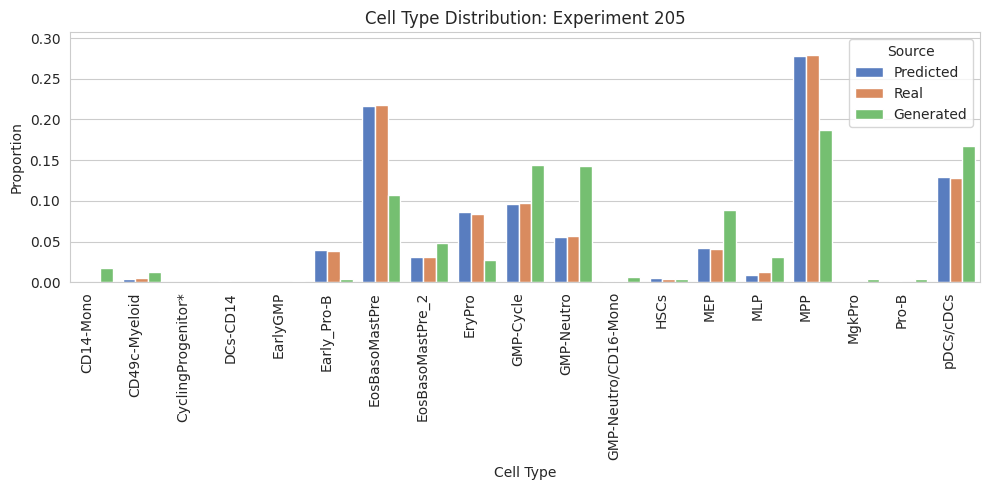

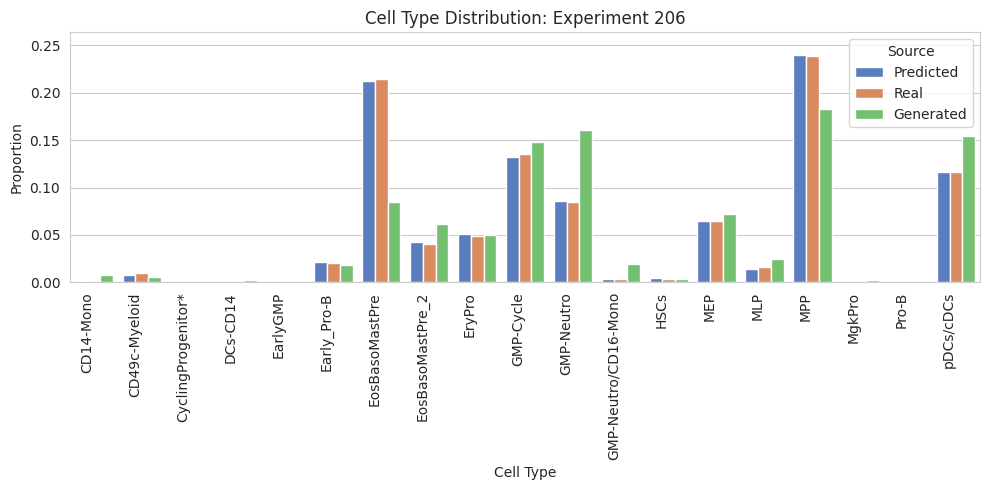

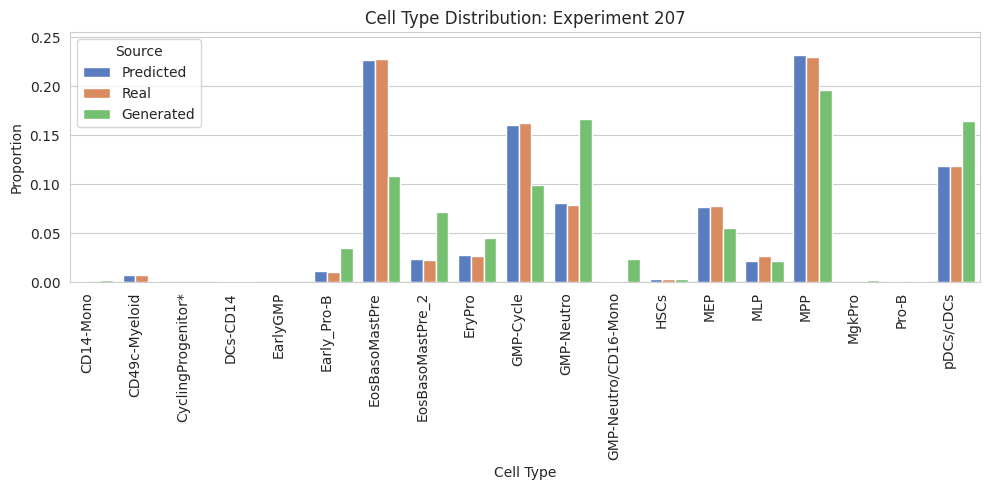

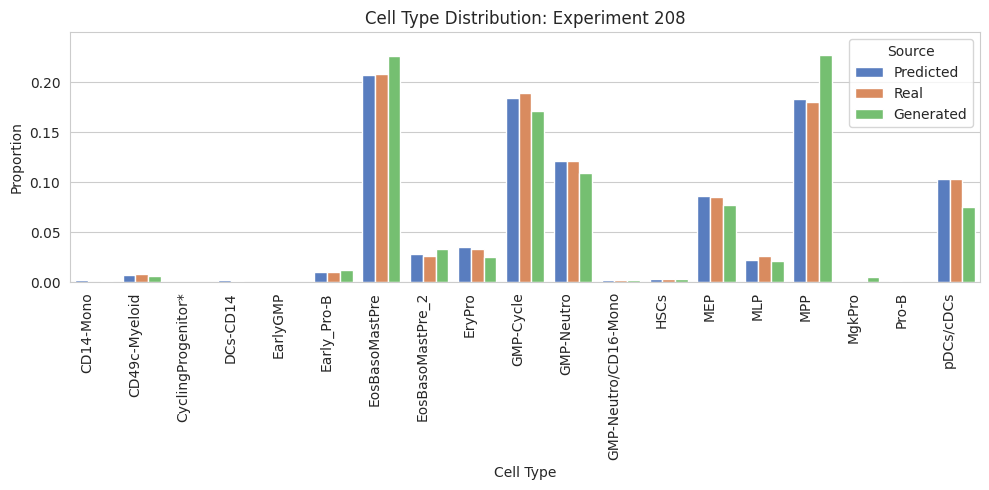

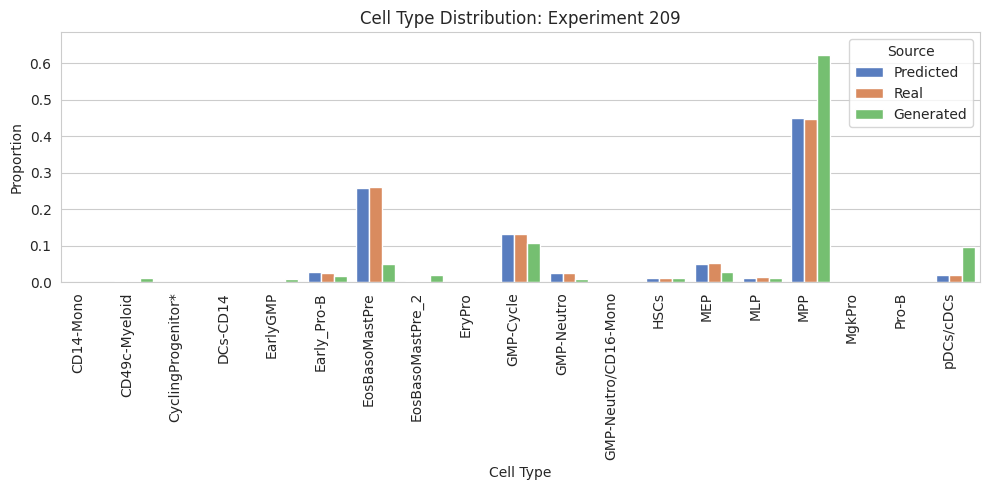

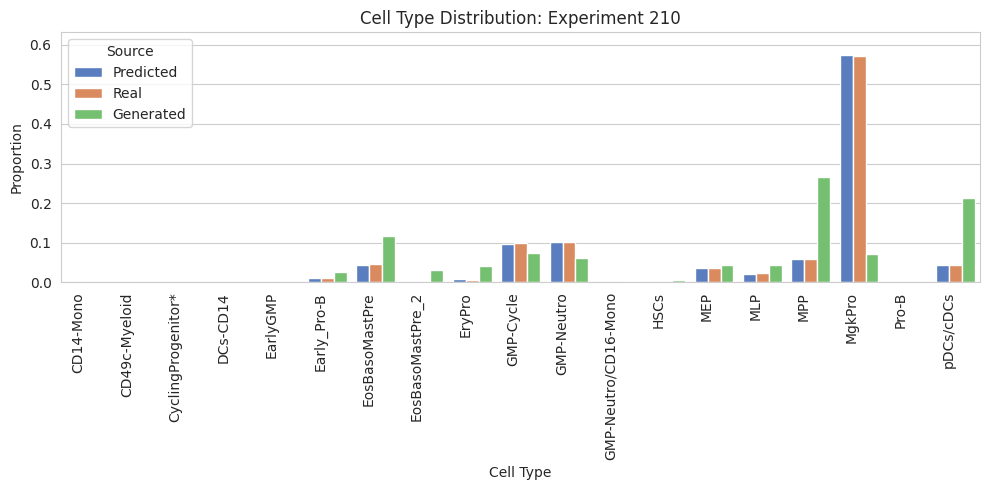

In [52]:
# retrieve mean cell types and define store for results
mean_ct_probs = sim_data["ct_probs"].mean(0)
exp_ct_props = {}

# iterate over the experiments
for idx, (exp_number, exp_idx) in enumerate(adata_real.obs.groupby("experiment_number").groups.items()):
    adata_exp = adata_real[exp_idx]

    # retrieve mean ct prob for each experiment
    gen_ct_probs = mean_ct_probs[idx]
    real_ct_counts = le_ct.transform(adata_exp.obs["cell_type"])
    
    # compute ground truth cell type proportion on real data
    real_ct_probs = np.zeros_like(gen_ct_probs)
    for idx in range(len(real_ct_probs)):
        mask = np.argwhere(real_ct_counts == idx)
        real_ct_probs[idx] = len(mask) / len(real_ct_counts)

    # predict cell type proportion on real data with classifier
    X_exp_resc = np.concat(
        [adata_exp.obsm["X_channel_standardized_class"], adata_exp.obsm["X_scatter_standardized_class"]], axis=-1
    )
    X_exp_rec = torch.from_numpy(X_exp_resc).float().to(cfm.device)
    ct_logits = classifier.predict(X_exp_rec)["cell_type"]
    pred_ct_probs = torch.nn.functional.softmax(ct_logits, dim=-1).detach().cpu().numpy().mean(0)

    exp_ct_props[exp_number] = {
        "pred": pred_ct_probs,
        "gen": gen_ct_probs,
        "real": real_ct_probs,
    }
    
    # 1. Prepare small dataframe for this specific experiment
    df_temp = pd.DataFrame({
        "Cell Type": np.tile(le_ct.classes_, 3),
        "Proportion": np.concatenate([pred_ct_probs, real_ct_probs, gen_ct_probs]),
        "Source": ["Predicted"] * len(le_ct.classes_) + ["Real"] * len(le_ct.classes_) + ["Generated"] * len(le_ct.classes_)
    })

    # 2. Create the figure
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_temp, x="Cell Type", y="Proportion", hue="Source", palette="muted")
    
    # 3. Formatting
    plt.title(f"Cell Type Distribution: Experiment {exp_number}")
    plt.xticks(rotation=90, ha='right')
    plt.ylabel("Proportion")
    plt.ylim(0, max(df_temp["Proportion"]) * 1.1) # Add a little headroom
    plt.tight_layout()
    
    # 4. Display or Save
    plt.savefig(
        os.path.join(dump_dir, f"ct_props_{exp_number}.png"),
        dpi=300
    )

### Plot Confusion Matrix.

In [38]:
# iterate over the experiments
for idx, (exp_number, exp_idx) in enumerate(adata_real.obs.groupby("experiment_number").groups.items()):
    adata_exp = adata_real[exp_idx]
    # retrieve mean ct prob for each experiment
    real_ct = le_ct.transform(adata_exp.obs["cell_type"])

    # predict cell type proportion on real data with classifier
    X_exp_resc = np.concat(
        [adata_exp.obsm["X_channel_standardized_class"], adata_exp.obsm["X_scatter_standardized_class"]], axis=-1
    )
    X_exp_rec = torch.from_numpy(X_exp_resc).float().to(cfm.device)
    ct_logits = classifier.predict(X_exp_rec)["cell_type"]
    pred_ct_probs = torch.nn.functional.softmax(ct_logits, dim=-1).detach().cpu().numpy()
    pred_ct_label = np.argmax(pred_ct_probs, axis=-1)
    print(f"{X_exp_resc.shape=} {pred_ct_label.shape=}, {real_ct.shape=}")

    

/tmp/ipykernel_3456450/829533946.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for idx, (exp_number, exp_idx) in enumerate(adata_real.obs.groupby("experiment_number").groups.items()):


X_exp_resc.shape=(12936, 27) pred_ct_label.shape=(12936,), real_ct.shape=(12936,)
X_exp_resc.shape=(20017, 27) pred_ct_label.shape=(20017,), real_ct.shape=(20017,)
X_exp_resc.shape=(15779, 27) pred_ct_label.shape=(15779,), real_ct.shape=(15779,)
X_exp_resc.shape=(25828, 27) pred_ct_label.shape=(25828,), real_ct.shape=(25828,)
X_exp_resc.shape=(5942, 27) pred_ct_label.shape=(5942,), real_ct.shape=(5942,)
X_exp_resc.shape=(19498, 27) pred_ct_label.shape=(19498,), real_ct.shape=(19498,)


### Prepare populations.

In [12]:
n_pops = 10
n_iters = 100
uq_data_per_cond = {}
ct_probs = sim_data["ct_probs"]
for idx, (exp_number, exp_idx) in tqdm(enumerate(adata_real.obs.groupby("experiment_number").groups.items())):
    pred_ct_probs = ct_probs[:, idx]
    populations = get_shuffled_populations(pred_ct_probs, n_pops=n_pops, n_iters=n_iters)
    uq_data_per_cond[exp_number] = populations

/tmp/ipykernel_3456450/4112932884.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for idx, (exp_number, exp_idx) in tqdm(enumerate(adata_real.obs.groupby("experiment_number").groups.items())):
6it [00:00, 19.37it/s]


### Compute Variance of Mean per cell type. 

In [13]:
uq_mean_std_mean = {}
uq_std_std_mean = {}
for exp_number, populations in uq_data_per_cond.items():
    mean_probs = populations.mean(-2)
    std_mean_probs = mean_probs.std(-2)
    shuffled_mean_std_mean_probs = std_mean_probs.mean(0)
    shuffled_std_std_mean_probs = std_mean_probs.std(0)
    uq_mean_std_mean[exp_number] = shuffled_mean_std_mean_probs
    uq_std_std_mean[exp_number] = shuffled_std_std_mean_probs


### Visualize results.

<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3456450/3682995477.py:40: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Mean $\sigma$ across shuffles", fontsize=12)


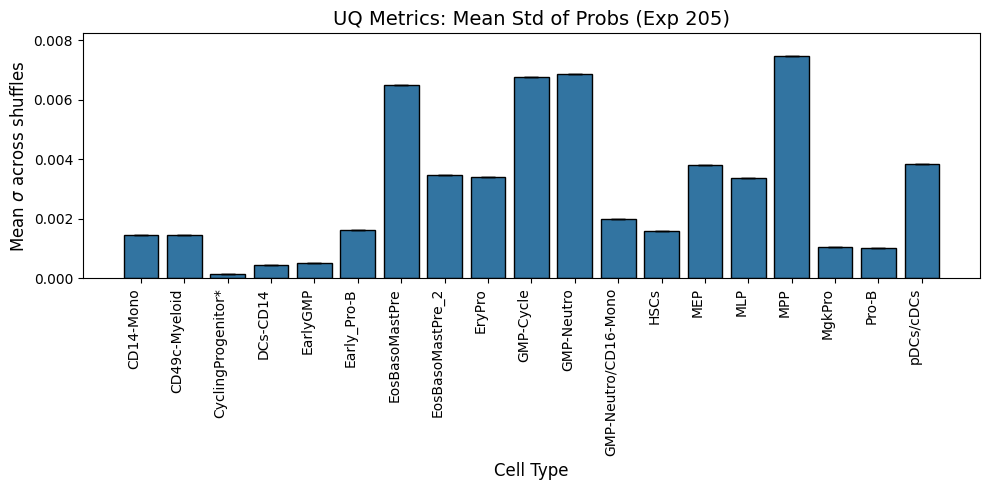

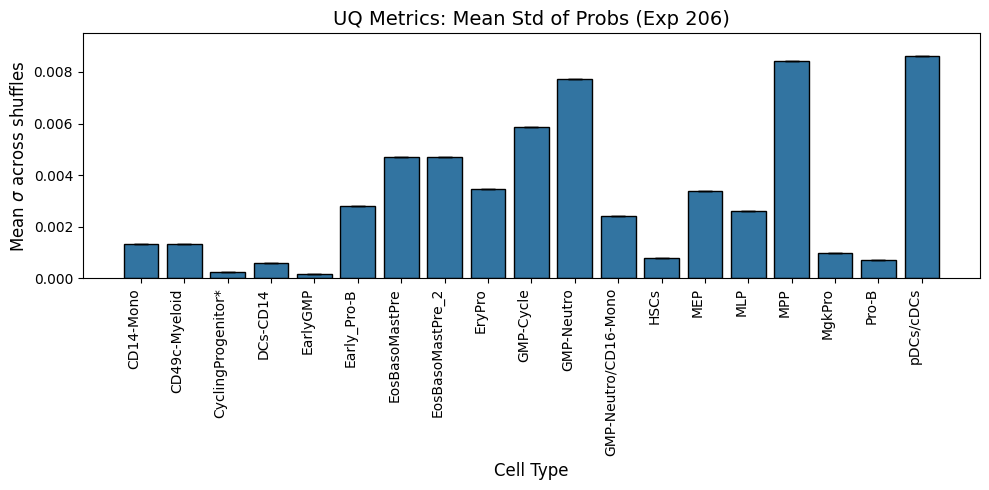

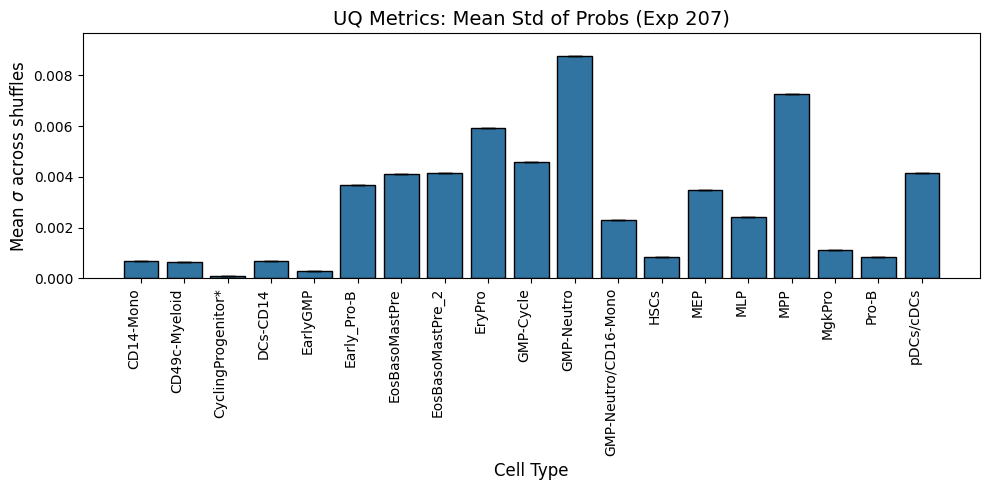

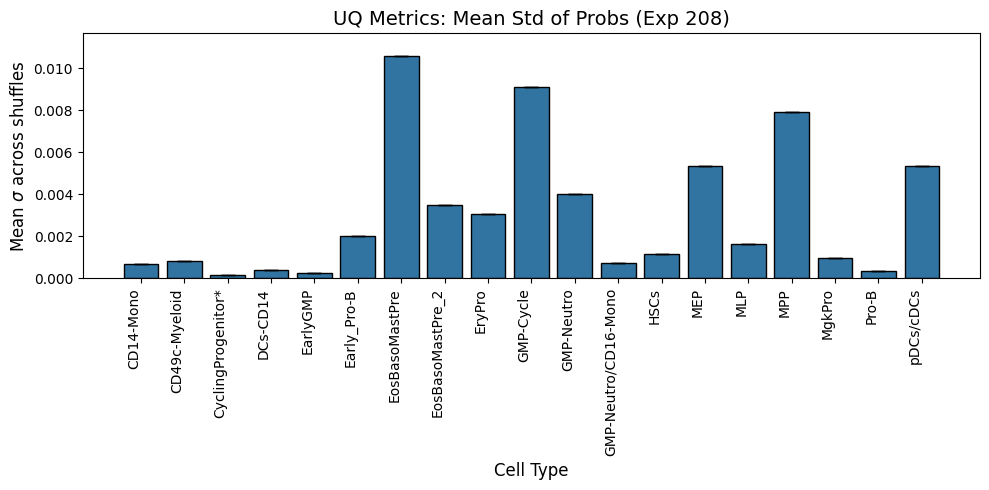

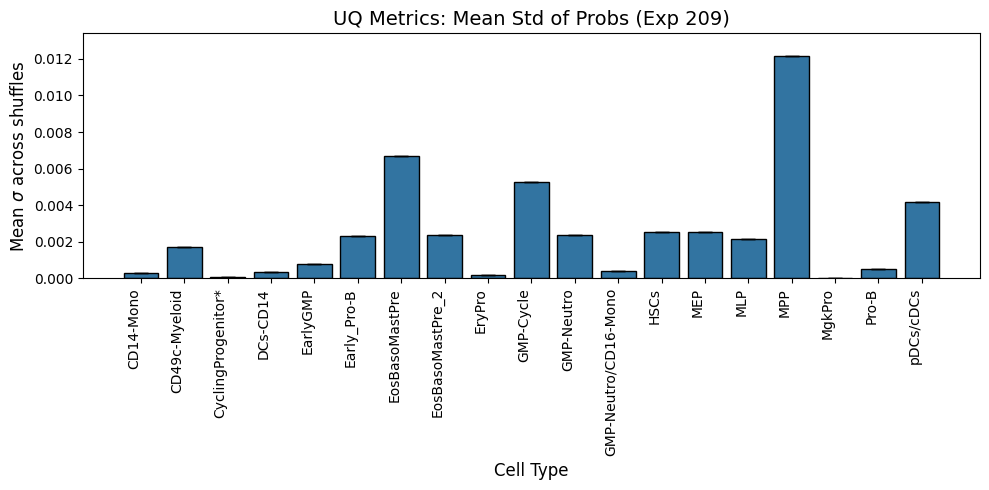

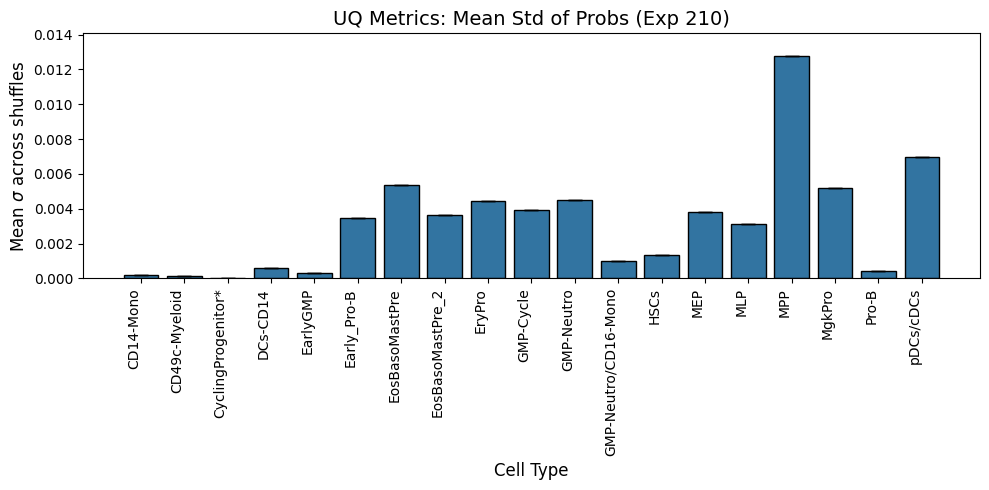

In [14]:
# Assuming uq_data_per_cond and le_ct are defined
cell_type_names = le_ct.classes_

for exp_number, populations in uq_data_per_cond.items():
    # --- Your calculation logic ---
    mean_probs = populations.mean(-2)
    std_mean_probs = mean_probs.std(-2)
    shuffled_mean_std_mean_probs = std_mean_probs.mean(0)
    shuffled_std_std_mean_probs = std_mean_probs.std(0)
    
    uq_mean_std_mean[exp_number] = shuffled_mean_std_mean_probs
    uq_std_std_mean[exp_number] = shuffled_std_std_mean_probs

    # --- PLOTTING PER EXPERIMENT ---
    
    plt.figure(figsize=(10, 5))
    
    # Create the bar plot for the mean uncertainty
    # x: Cell Type names, y: The mean of the standard deviations
    sns.barplot(
        x=cell_type_names, 
        y=shuffled_mean_std_mean_probs,
        # palette="magma",
        edgecolor="black"
    )

    # Add error bars manually using the std_std_mean
    plt.errorbar(
        x=np.arange(len(cell_type_names)), 
        y=shuffled_mean_std_mean_probs, 
        yerr=shuffled_std_std_mean_probs, 
        fmt='none', 
        c='black', 
        capsize=5
    )

    # Formatting
    plt.title(f"UQ Metrics: Mean Std of Probs (Exp {exp_number})", fontsize=14)
    plt.xlabel("Cell Type", fontsize=12)
    plt.ylabel("Mean $\sigma$ across shuffles", fontsize=12)
    plt.xticks(rotation=90, ha='right')
    
    # Optional: adjust y-axis to make room for error bars
    y_max = (shuffled_mean_std_mean_probs + shuffled_std_std_mean_probs).max()
    plt.ylim(0, y_max * 1.1)
    
    plt.tight_layout()
    # 4. Display or Save
    plt.savefig(
        os.path.join(dump_dir, f"ct_props_uq_mean_std_{exp_number}.png"),
        dpi=300
    )
    plt.show()



### Displaying sum of standard deviations.

<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3456450/1709283562.py:37: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Sum of Mean $\sigma$ across Cell Types")
/tmp/ipykernel_3456450/1709283562.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


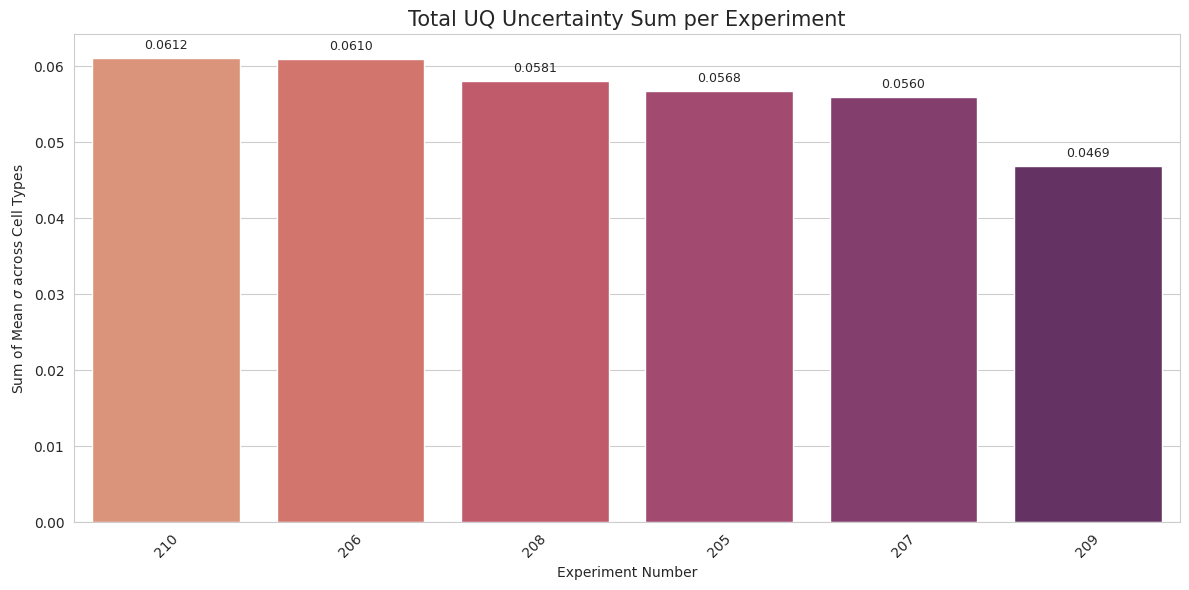

In [15]:
# Assuming uq_data_per_cond and le_ct are defined
cell_type_names = le_ct.classes_

uq_mean_std_mean_sum = {}

for exp_number, populations in uq_data_per_cond.items():
    # --- Your calculation logic ---
    mean_probs = populations.mean(-2)
    std_mean_probs = mean_probs.std(-2)
    shuffled_mean_std_mean_probs = std_mean_probs.mean(0)
    shuffled_std_std_mean_probs = std_mean_probs.std(0)
    
    uq_mean_std_mean_sum[exp_number] = shuffled_mean_std_mean_probs.sum()

#  1. Convert dictionary to DataFrame for Seaborn
summary_df = pd.DataFrame({
    "Experiment": list(uq_mean_std_mean_sum.keys()),
    "Total Uncertainty": list(uq_mean_std_mean_sum.values())
})

# Optional: Sort by uncertainty to see the most/least stable experiments
summary_df = summary_df.sort_values("Total Uncertainty", ascending=False)

# 2. Plotting
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=summary_df, 
    x="Experiment", 
    y="Total Uncertainty", 
    palette="flare"
)

# 3. Aesthetics
plt.title("Total UQ Uncertainty Sum per Experiment", fontsize=15)
plt.ylabel("Sum of Mean $\sigma$ across Cell Types")
plt.xlabel("Experiment Number")
plt.xticks(rotation=45)

# Add value labels on top of bars for precision
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()

# 4. Display or Save
plt.savefig(
    os.path.join(dump_dir, f"ct_props_uq_mean_sum_std.png"),
    dpi=300
)
plt.show()

plt.show()

### Compare cell states.

In [16]:
from collections import defaultdict

exp_numbers = sorted(adata_real.obs["experiment_number"].unique())

edist_dict = defaultdict(list)

for gen_idx, gen_exp_number in enumerate(exp_numbers):
    # retrieve simulations for current experiment
    X_channel_gen = sim_data["X_channel"][:, gen_idx, :]
    X_scatter_gen = sim_data["X_scatter"][:, gen_idx, :]

    print(f"g:{gen_exp_number} -> GENERATED: {X_channel_gen.shape=}, {X_scatter_gen.shape=} -> {gen_idx+1}/{len(exp_numbers)}")

    for idx, exp_number in enumerate(exp_numbers):
        # retrieve real data
        adata_exp = adata_real[adata_real.obs["experiment_number"] == exp_number]
        X_channel_real = adata_exp.obsm["X_channel_standardized"]
        X_scatter_real = adata_exp.obsm["X_scatter_standardized"]
        print(f"g:{gen_exp_number}/r:{exp_number} -> REAL: {X_channel_real.shape=}, {X_scatter_real.shape=} -> g:{gen_idx+1}/{len(exp_numbers)} | r:{idx+1}/{len(exp_numbers)}")
        edist = compute_e_distance(X_channel_gen, X_channel_real)
        edist_dict["gen_exp_number"].append(gen_exp_number)
        edist_dict["real_exp_number"].append(exp_number)
        edist_dict["edist"].append(edist)
distance_df = pd.DataFrame(edist_dict).sort_values("edist", axis=0, ascending=False)
distance_df

g:205 -> GENERATED: X_channel_gen.shape=(20000, 21), X_scatter_gen.shape=(20000, 6) -> 1/6
g:205/r:205 -> REAL: X_channel_real.shape=(12936, 21), X_scatter_real.shape=(12936, 6) -> g:1/6 | r:1/6
g:205/r:206 -> REAL: X_channel_real.shape=(20017, 21), X_scatter_real.shape=(20017, 6) -> g:1/6 | r:2/6
g:205/r:207 -> REAL: X_channel_real.shape=(15779, 21), X_scatter_real.shape=(15779, 6) -> g:1/6 | r:3/6
g:205/r:208 -> REAL: X_channel_real.shape=(25828, 21), X_scatter_real.shape=(25828, 6) -> g:1/6 | r:4/6
g:205/r:209 -> REAL: X_channel_real.shape=(5942, 21), X_scatter_real.shape=(5942, 6) -> g:1/6 | r:5/6
g:205/r:210 -> REAL: X_channel_real.shape=(19498, 21), X_scatter_real.shape=(19498, 6) -> g:1/6 | r:6/6
g:206 -> GENERATED: X_channel_gen.shape=(20000, 21), X_scatter_gen.shape=(20000, 6) -> 2/6
g:206/r:205 -> REAL: X_channel_real.shape=(12936, 21), X_scatter_real.shape=(12936, 6) -> g:2/6 | r:1/6
g:206/r:206 -> REAL: X_channel_real.shape=(20017, 21), X_scatter_real.shape=(20017, 6) -> g:

,gen_exp_number,real_exp_number,edist
29,209,210,500.286418
23,208,210,465.605259
11,206,210,465.103061
5,205,210,464.558826
17,207,210,463.718572
35,210,210,368.088873
34,210,209,21.458213
30,210,205,18.022899
27,209,208,16.309132
25,209,206,16.151034


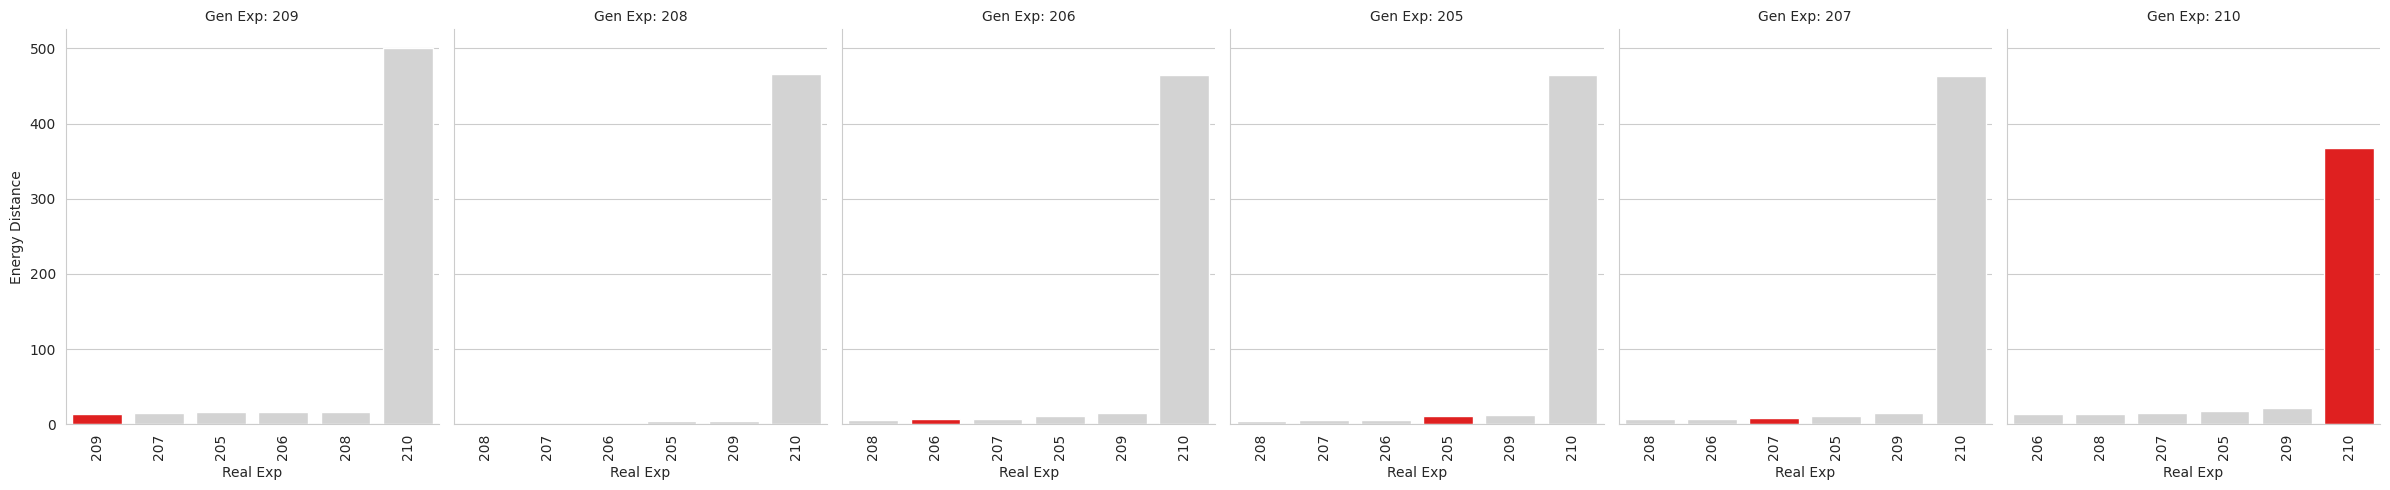

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Flag the matches for conditional coloring
distance_df['is_match'] = distance_df['gen_exp_number'] == distance_df['real_exp_number']

# 2. Setup the FacetGrid in one row (no col_wrap)
g = sns.FacetGrid(
    distance_df, 
    col="gen_exp_number", 
    height=5, 
    aspect=0.8, 
    sharex=False
)

# 3. Define the plotting function to sort bars and color them
def plot_sorted_gray_red(data, **kwargs):
    # Sort by 'edist' to follow bar sorting guidelines
    data_sorted = data.sort_values("edist")
    
    # Plot bars: Red for the match, Gray for others
    sns.barplot(
        data=data_sorted, 
        x="real_exp_number", 
        y="edist", 
        hue="is_match", 
        palette={True: "red", False: "lightgray"}, 
        dodge=False
    )

# 4. Map to the grid
g.map_dataframe(plot_sorted_gray_red)

# 5. Final Formatting
g.set_axis_labels("Real Exp", "Energy Distance")
g.set_titles("Gen Exp: {col_name}")

# Remove individual legends from each facet
for ax in g.axes.flat:
    if ax.get_legend():
        ax.get_legend().remove()
    ax.tick_params(axis='x', rotation=90) # Rotate labels for clarity in single row

plt.tight_layout()
# plt.savefig("energy_distance_single_row.png")

In [ ]:
stats_list = []

for gen_idx, gen_exp_number in enumerate(exp_numbers):
    # Combine generated channels and scatter
    X_gen = np.hstack([sim_data["X_channel"][:, gen_idx, :], 
                       sim_data["X_scatter"][:, gen_idx, :]])
    print(X_gen.shape)
    # Compute stats per dimension (axis=0)
    mean_gen = np.mean(X_gen, axis=0)
    std_gen = np.std(X_gen, axis=0)

    for idx, exp_number in enumerate(exp_numbers):
        # Retrieve and combine real data
        adata_exp = adata_real[adata_real.obs["experiment_number"] == exp_number]
        X_real = np.hstack([adata_exp.obsm["X_channel_standardized"], 
                            adata_exp.obsm["X_scatter_standardized"]])
        print(X_real.shape)    
        mean_real = np.mean(X_real, axis=0)
        std_real = np.std(X_real, axis=0)
        
        # Store for plotting (one row per dimension/feature)
        for i in range(X_gen.shape[1]):
            stats_list.append({
                "gen_exp": gen_exp_number,
                "real_exp": exp_number,
                "dim_idx": i,
                "mean_gen": mean_gen[i],
                "mean_real": mean_real[i],
                "std_gen": std_gen[i],
                "std_real": std_real[i],
                "is_match": gen_exp_number == exp_number
            })

df_stats = pd.DataFrame(stats_list)

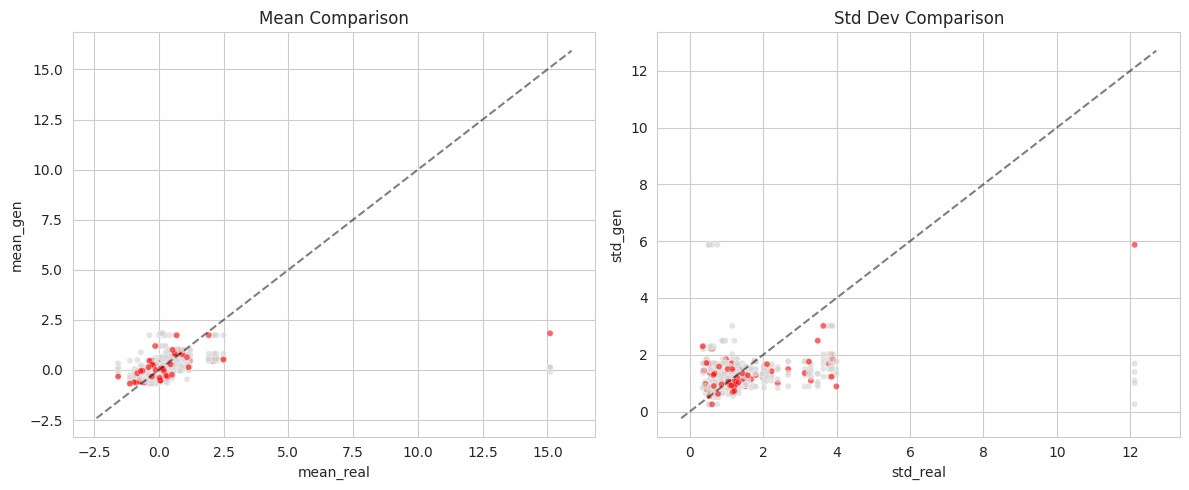

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot settings
plot_params = [
    ("mean_real", "mean_gen", "Mean Comparison", axes[0]),
    ("std_real", "std_gen", "Std Dev Comparison", axes[1])
]

for x_col, y_col, title, ax in plot_params:
    # Plot non-matches in gray first, then matches in red
    sns.scatterplot(
        data=df_stats, x=x_col, y=y_col, hue="is_match",
        palette={True: "red", False: "lightgray"}, alpha=0.6, ax=ax, s=20
    )
    
    # Add X=Y identity line
    lo, hi = ax.get_xlim(), ax.get_ylim()
    min_val, max_val = min(lo[0], hi[0]), max(lo[1], hi[1])
    ax.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", alpha=0.5)
    
    ax.set_title(title)
    ax.get_legend().remove()

plt.tight_layout()
plt.show()

In [ ]:
from collections import defaultdict

exp_numbers = sorted(adata_real.obs["experiment_number"].unique())

edist_dict_rr = defaultdict(list)

for gen_idx, gen_exp_number in enumerate(exp_numbers):
    # retrieve simulations for current experiment

    adata_exp_i = adata_real[adata_real.obs["experiment_number"] == gen_exp_number]
    X_channel_gen = adata_exp_i.obsm["X_channel_standardized"]
    X_scatter_gen = adata_exp_i.obsm["X_scatter_standardized"]

    print(f"g:{gen_exp_number} -> GENERATED: {X_channel_gen.shape=}, {X_scatter_gen.shape=} -> {gen_idx+1}/{len(exp_numbers)}")

    for idx, exp_number in enumerate(exp_numbers):
        # retrieve real data
        adata_exp = adata_real[adata_real.obs["experiment_number"] == exp_number]
        X_channel_real = adata_exp.obsm["X_channel_standardized"]
        X_scatter_real = adata_exp.obsm["X_scatter_standardized"]
        print(f"g:{gen_exp_number}/r:{exp_number} -> REAL: {X_channel_real.shape=}, {X_scatter_real.shape=} -> g:{gen_idx+1}/{len(exp_numbers)} | r:{idx+1}/{len(exp_numbers)}")
        edist = compute_e_distance(X_channel_gen, X_channel_real)
        edist_dict_rr["gen_exp_number"].append(gen_exp_number)
        edist_dict_rr["real_exp_number"].append(exp_number)
        edist_dict_rr["edist"].append(edist)
distance_df_rr = pd.DataFrame(edist_dict_rr).sort_values("edist", axis=0, ascending=False)
distance_df_rr

g:205 -> GENERATED: X_channel_gen.shape=(12936, 21), X_scatter_gen.shape=(12936, 6) -> 1/6
g:205/r:205 -> REAL: X_channel_real.shape=(12936, 21), X_scatter_real.shape=(12936, 6) -> g:1/6 | r:1/6
g:205/r:206 -> REAL: X_channel_real.shape=(20017, 21), X_scatter_real.shape=(20017, 6) -> g:1/6 | r:2/6
g:205/r:207 -> REAL: X_channel_real.shape=(15779, 21), X_scatter_real.shape=(15779, 6) -> g:1/6 | r:3/6
g:205/r:208 -> REAL: X_channel_real.shape=(25828, 21), X_scatter_real.shape=(25828, 6) -> g:1/6 | r:4/6
g:205/r:209 -> REAL: X_channel_real.shape=(5942, 21), X_scatter_real.shape=(5942, 6) -> g:1/6 | r:5/6
g:205/r:210 -> REAL: X_channel_real.shape=(19498, 21), X_scatter_real.shape=(19498, 6) -> g:1/6 | r:6/6


g:206 -> GENERATED: X_channel_gen.shape=(20017, 21), X_scatter_gen.shape=(20017, 6) -> 2/6
g:206/r:205 -> REAL: X_channel_real.shape=(12936, 21), X_scatter_real.shape=(12936, 6) -> g:2/6 | r:1/6
g:206/r:206 -> REAL: X_channel_real.shape=(20017, 21), X_scatter_real.shape=(20017, 6) -> g:2/6 | r:2/6
g:206/r:207 -> REAL: X_channel_real.shape=(15779, 21), X_scatter_real.shape=(15779, 6) -> g:2/6 | r:3/6
g:206/r:208 -> REAL: X_channel_real.shape=(25828, 21), X_scatter_real.shape=(25828, 6) -> g:2/6 | r:4/6
g:206/r:209 -> REAL: X_channel_real.shape=(5942, 21), X_scatter_real.shape=(5942, 6) -> g:2/6 | r:5/6
g:206/r:210 -> REAL: X_channel_real.shape=(19498, 21), X_scatter_real.shape=(19498, 6) -> g:2/6 | r:6/6
g:207 -> GENERATED: X_channel_gen.shape=(15779, 21), X_scatter_gen.shape=(15779, 6) -> 3/6
g:207/r:205 -> REAL: X_channel_real.shape=(12936, 21), X_scatter_real.shape=(12936, 6) -> g:3/6 | r:1/6
g:207/r:206 -> REAL: X_channel_real.shape=(20017, 21), X_scatter_real.shape=(20017, 6) -> g:

,gen_exp_number,real_exp_number,edist
29,209,210,476.388063
34,210,209,476.388063
30,210,205,475.918117
5,205,210,475.918117
32,210,207,471.497445
17,207,210,471.497445
33,210,208,470.734438
23,208,210,470.734438
11,206,210,469.115224
31,210,206,469.115224


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

stats_rr_list = []

for gen_idx, gen_exp_number in enumerate(exp_numbers):
    # Retrieve 'Reference' Real Data (acting as 'gen' in this RR loop)
    adata_exp_i = adata_real[adata_real.obs["experiment_number"] == gen_exp_number]
    X_gen = np.hstack([adata_exp_i.obsm["X_channel_standardized"], 
                       adata_exp_i.obsm["X_scatter_standardized"]])
    
    # Stats per dimension (feature)
    mean_gen = np.mean(X_gen, axis=0)
    std_gen = np.std(X_gen, axis=0)

    for idx, exp_number in enumerate(exp_numbers):
        # Retrieve 'Target' Real Data
        adata_exp = adata_real[adata_real.obs["experiment_number"] == exp_number]
        X_real = np.hstack([adata_exp.obsm["X_channel_standardized"], 
                            adata_exp.obsm["X_scatter_standardized"]])
        
        mean_real = np.mean(X_real, axis=0)
        std_real = np.std(X_real, axis=0)
        
        # Capture stats for every single dimension/feature
        for d in range(X_gen.shape[1]):
            stats_rr_list.append({
                "gen_exp": gen_exp_number,
                "real_exp": exp_number,
                "dim_idx": d,
                "mean_ref": mean_gen[d],
                "mean_target": mean_real[d],
                "std_ref": std_gen[d],
                "std_target": std_real[d],
                "is_match": gen_exp_number == exp_number
            })

df_stats_rr = pd.DataFrame(stats_rr_list)

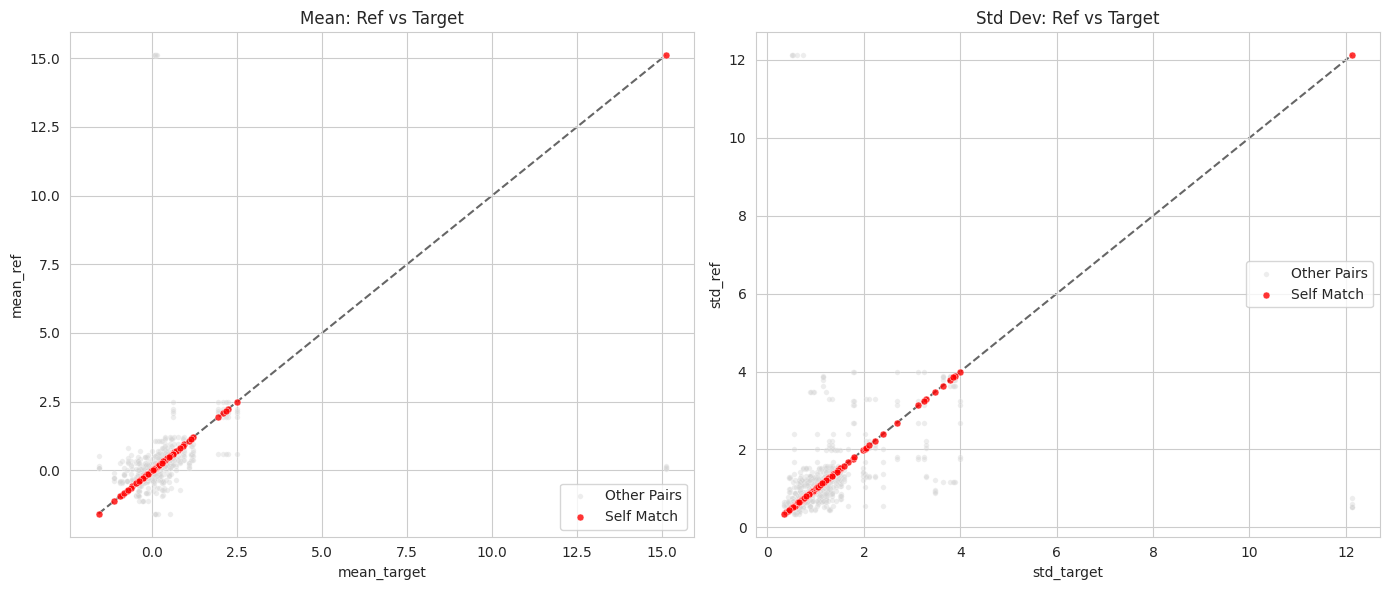

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_configs = [
    ("mean_target", "mean_ref", "Mean: Ref vs Target", axes[0]),
    ("std_target", "std_ref", "Std Dev: Ref vs Target", axes[1])
]

for x_col, y_col, title, ax in plot_configs:
    # 1. Plot non-matches in gray (background)
    sns.scatterplot(
        data=df_stats_rr[~df_stats_rr['is_match']], 
        x=x_col, y=y_col, color="lightgray", alpha=0.4, ax=ax, s=15, label="Other Pairs"
    )
    # 2. Plot self-matches in red (foreground)
    sns.scatterplot(
        data=df_stats_rr[df_stats_rr['is_match']], 
        x=x_col, y=y_col, color="red", alpha=0.8, ax=ax, s=25, label="Self Match"
    )
    
    # 3. Add the X=Y Identity Line
    max_val = max(df_stats_rr[x_col].max(), df_stats_rr[y_col].max())
    min_val = min(df_stats_rr[x_col].min(), df_stats_rr[y_col].min())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.6, zorder=0)
    
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

### Annotate Predictions.

In [59]:
only_true_exp = False
exp2adata = {}


# retrieve reference data
X_channel_ref = adata_class.obsm["X_channel_renormalized"]
X_scatter_ref = adata_class.obsm["X_scatter_renormalized"]

for gen_idx, gen_exp_number in enumerate(exp_numbers):
    print(gen_idx, gen_exp_number)
    if gen_exp_number != "210":
        continue
    # retrieve simulations for current experiment
    X_channel_gen = sim_data["X_channel"][:, gen_idx, :]
    X_scatter_gen = sim_data["X_scatter"][:, gen_idx, :]
    ct_probs_gen = sim_data["ct_probs"][:, gen_idx, :]

    # retrieve real data for current experiment
    tgt_exp_mask = adata_real.obs["experiment_number"] == gen_exp_number
    if only_true_exp:
        adata_exp = adata_real[tgt_exp_mask]
    else:
        adata_exp = adata_real
    X_channel_real = adata_exp.obsm["X_channel_standardized"]
    X_scatter_real = adata_exp.obsm["X_scatter_standardized"]

    # compute cell type
    ct_gen = le_ct.inverse_transform(
        ct_probs_gen.argmax(-1)
    )

    # create adata
    adata_exp_concat = sc.AnnData(
        X=np.concatenate(
            (
                X_channel_ref,
                X_channel_real,
                X_channel_gen,
            ),
            axis=0
        ),
        obs={
            "experiment_number": adata_class.obs["experiment_number"].tolist() + \
                adata_exp.obs["experiment_number"].tolist() + \
                [gen_exp_number for _ in range(X_channel_gen.shape[0])],
            "cell_type": adata_class.obs["cell_type"].tolist() + \
                adata_exp.obs["cell_type"].tolist() + \
                ct_gen.tolist(),
            "dataset_type": ["ref" for _ in range(adata_class.shape[0])] + \
                ["new" for _ in range(adata_exp.shape[0])] + \
                ["gen" for _ in range(X_channel_gen.shape[0])],
            "is_real_target": [False for _ in range(adata_class.shape[0])] + \
                tgt_exp_mask.tolist() + \
                [False for _ in range(X_channel_gen.shape[0])],
        },
        obsm={
            "X_scatter": np.concatenate(
                (
                    X_scatter_ref,
                    X_scatter_real,
                    X_scatter_gen,
                ),
                axis=0
            ),
        }
    )
    print(f"{gen_exp_number} -> {adata_exp_concat}")
    sc.pp.pca(adata_exp_concat)
    sc.pp.neighbors(adata_exp_concat)
    sc.tl.umap(adata_exp_concat)
    # sc.pl.embedding(adata_exp_concat, "umap", color=["is_real_target","dataset_type"])
    exp2adata[gen_exp_number] = adata_exp_concat

0 205
1 206
2 207
3 208
4 209
5 210
210 -> AnnData object with n_obs × n_vars = 259976 × 21
    obs: 'experiment_number', 'cell_type', 'dataset_type', 'is_real_target'
    obsm: 'X_scatter'


/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


### Visualize predictions.

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not array(['MPP', 'EosBasoMastPre', 'GMP-Cycle', ..., 'MPP', 'MPP',
       'pDCs/cDCs'], shape=(20000,), dtype=object)

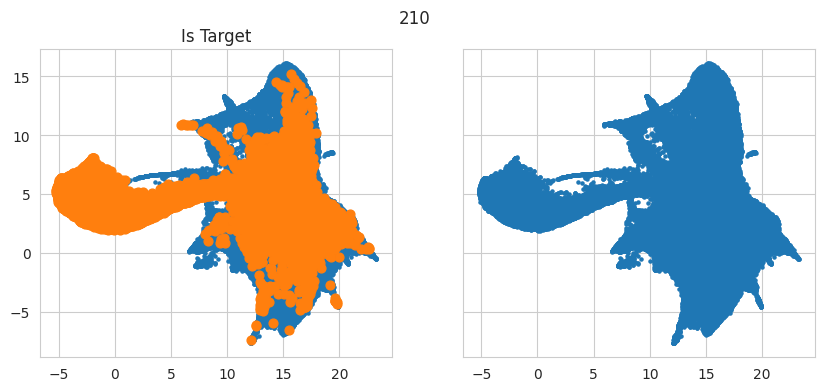

In [62]:
for key, exp_adata in exp2adata.items():
    X_umap = exp_adata.obsm["X_umap"]
    ct_values = exp_adata.obs["cell_type"].values
    ct_mask = (exp_adata.obs["experiment_number"] == key) & (exp_adata.obs["dataset_type"] == "new")
    gen_mask = exp_adata.obs["dataset_type"] == "gen"
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
    fig.suptitle(key)
    axes[0].scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        s=5,
    )
    axes[0].scatter(
        X_umap[ct_mask, 0],
        X_umap[ct_mask, 1],
        s=40,
    )
    axes[0].set_title(f"Is Target")
    axes[0].grid(1)

    axes[1].scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        s=5,
    )
    axes[1].scatter(
        X_umap[gen_mask, 0],
        X_umap[gen_mask, 1],
        s=40,
        c=ct_values[gen_mask]
    )
    axes[1].set_title("Is Generated")
    axes[1].grid(1)

    for ax in axes:
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")

    plt.savefig(os.path.join(dump_dir, f"umap_{key}.png"))
    plt.close()

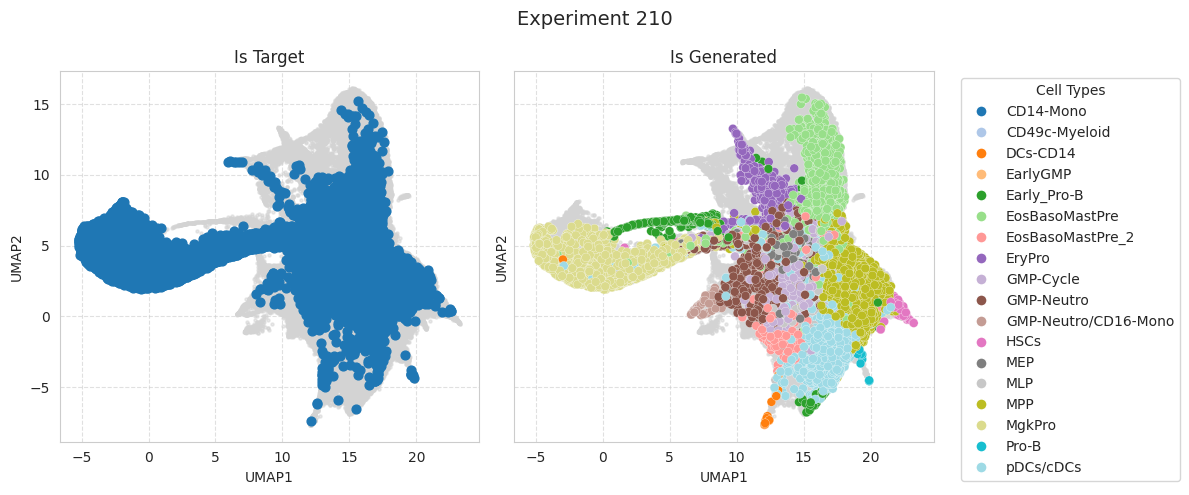

In [64]:
import os
import numpy as np
import matplotlib.pyplot as plt

for key, exp_adata in exp2adata.items():
    X_umap = exp_adata.obsm["X_umap"]
    ct_values = exp_adata.obs["cell_type"].values
    
    ct_mask = (exp_adata.obs["experiment_number"] == key) & (exp_adata.obs["dataset_type"] == "new")
    gen_mask = exp_adata.obs["dataset_type"] == "gen"
    
    # Increase figsize slightly to make room for the legend
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    fig.suptitle(f"Experiment {key}", fontsize=14)

    # --- Subplot 1: Target ---
    # Plot background (all cells) in light gray so the target cells pop
    axes[0].scatter(X_umap[:, 0], X_umap[:, 1], s=5, c="lightgray", alpha=0.5)
    
    # Plot target cells
    axes[0].scatter(X_umap[ct_mask, 0], X_umap[ct_mask, 1], s=40, c="tab:blue")
    axes[0].set_title("Is Target")
    axes[0].grid(True, linestyle="--", alpha=0.6)

    # --- Subplot 2: Generated ---
    # Plot background in light gray
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], s=5, c="lightgray", alpha=0.5)

    # Create a color map for the unique cell types in the generated mask
    unique_cts = np.unique(ct_values[gen_mask])
    # Use tab10 if you have <=10 cell types, otherwise tab20
    cmap_name = "tab10" if len(unique_cts) <= 10 else "tab20"
    cmap = plt.get_cmap(cmap_name)
    
    # Map each cell type to a specific color from the colormap
    color_dict = {ct: cmap(i / max(1, len(unique_cts) - 1)) for i, ct in enumerate(unique_cts)}
    gen_colors = [color_dict[ct] for ct in ct_values[gen_mask]]

    # Plot generated cells using the explicit color list
    axes[1].scatter(
        X_umap[gen_mask, 0],
        X_umap[gen_mask, 1],
        s=40,
        c=gen_colors,
        edgecolors='white', # Adding a tiny border helps them stand out
        linewidth=0.2
    )
    axes[1].set_title("Is Generated")
    axes[1].grid(True, linestyle="--", alpha=0.6)

    # --- Formatting & Legend ---
    for ax in axes:
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")

    # Create custom legend handles based on the color dictionary
    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[ct], markersize=8) 
        for ct in unique_cts
    ]
    axes[1].legend(
        legend_handles, 
        unique_cts, 
        title="Cell Types", 
        bbox_to_anchor=(1.05, 1), # Places legend outside the plot
        loc='upper left'
    )

    # tight_layout ensures the external legend doesn't get cut off when saving
    plt.tight_layout()
    plt.show()
    # plt.savefig(os.path.join(dump_dir, f"umap_{key}.png"), dpi=300)
    # plt.close()

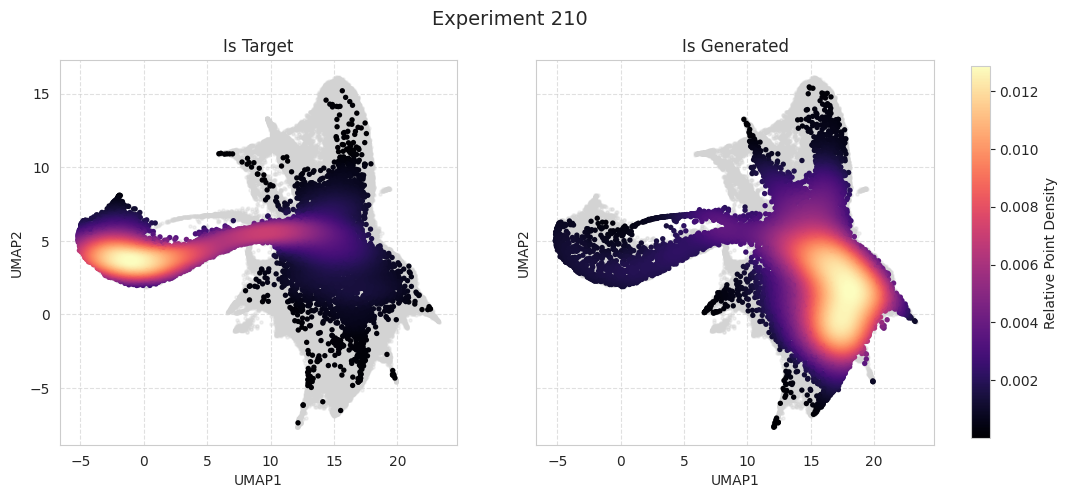

In [66]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

for key, exp_adata in exp2adata.items():
    X_umap = exp_adata.obsm["X_umap"]
    
    ct_mask = (exp_adata.obs["experiment_number"] == key) & (exp_adata.obs["dataset_type"] == "new")
    gen_mask = exp_adata.obs["dataset_type"] == "gen"
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    fig.suptitle(f"Experiment {key}", fontsize=14)

    def plot_density(ax, mask):
        # Background cells
        ax.scatter(X_umap[:, 0], X_umap[:, 1], s=5, c="lightgray", alpha=0.3)
        
        x = X_umap[mask, 0]
        y = X_umap[mask, 1]
        
        if len(x) > 1:
            xy = np.vstack([x, y])
            
            # 1. Subsample up to 1,000 points to fit the KDE
            n_samples = min(len(x), 1000)
            subsample_idx = np.random.choice(len(x), size=n_samples, replace=False)
            xy_subsampled = xy[:, subsample_idx]
            
            # 2. Fit KDE on the subsample, evaluate on ALL points
            kde = gaussian_kde(xy_subsampled)
            z = kde(xy) 
            
            # 3. Sort points by density so densest are plotted on top
            idx_sort = z.argsort()
            x, y, z = x[idx_sort], y[idx_sort], z[idx_sort]
            
            # Plot (adjusted s=15 for better visibility with high point counts)
            sc = ax.scatter(x, y, s=15, c=z, cmap='magma', edgecolor='none')
            return sc
        else:
            # Fallback for empty/tiny groups
            ax.scatter(x, y, s=15, c='black')
            return None

    # --- Subplot 1: Target ---
    sc_target = plot_density(axes[0], ct_mask)
    axes[0].set_title("Is Target")
    axes[0].grid(True, linestyle="--", alpha=0.6)

    # --- Subplot 2: Generated ---
    sc_gen = plot_density(axes[1], gen_mask)
    axes[1].set_title("Is Generated")
    axes[1].grid(True, linestyle="--", alpha=0.6)

    # --- Formatting & Colorbar ---
    for ax in axes:
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")

    if sc_gen:
        cbar = fig.colorbar(sc_gen, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
        cbar.set_label('Relative Point Density')

    # plt.savefig(os.path.join(dump_dir, f"umap_density_{key}.png"), dpi=300)
    plt.show()
    # plt.close()

### Concatenating Only Real Data Using Base Representation.

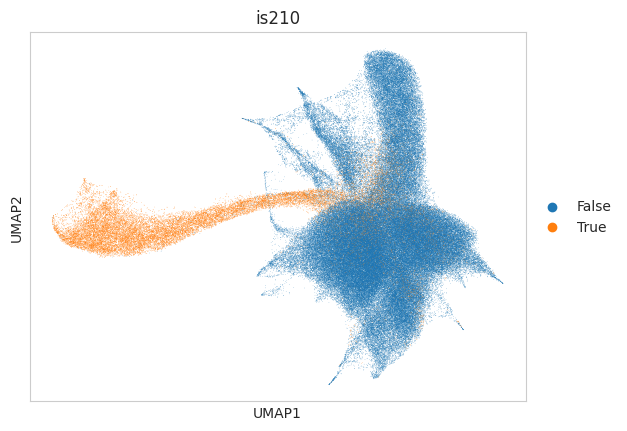

In [ ]:
adata_exp_concat_real = sc.AnnData(
X=np.concatenate(
    (
        X_channel_ref,
        X_channel_real,
    ),
    axis=0
))
sc.pp.pca(adata_exp_concat_real)
sc.pp.neighbors(adata_exp_concat_real)
sc.tl.umap(adata_exp_concat_real)

# prepare obs
obs=pd.DataFrame({
    "experiment_number": adata_class.obs["experiment_number"].tolist() + \
        adata_exp.obs["experiment_number"].tolist()
})
adata_exp_concat_real.obs = obs
adata_exp_concat_real.obs["is210"] = adata_exp_concat_real.obs["experiment_number"] == "210"

sc.pl.embedding(adata_exp_concat_real, "umap", color="is210")


### Concatenating Only Real Data Using Original Representation.

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


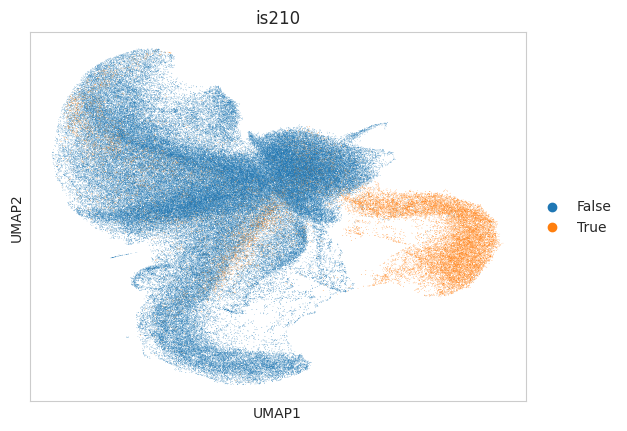

In [ ]:
adata_concat = sc.concat((adata_class, adata_real), uns_merge="same")
sc.pp.pca(adata_concat)
sc.pp.neighbors(adata_concat)
sc.tl.umap(adata_concat)
adata_concat.obs["is210"] = adata_concat.obs["experiment_number"] == "210"
sc.pl.embedding(adata_concat, "umap", color="is210")


### Plot Marginals

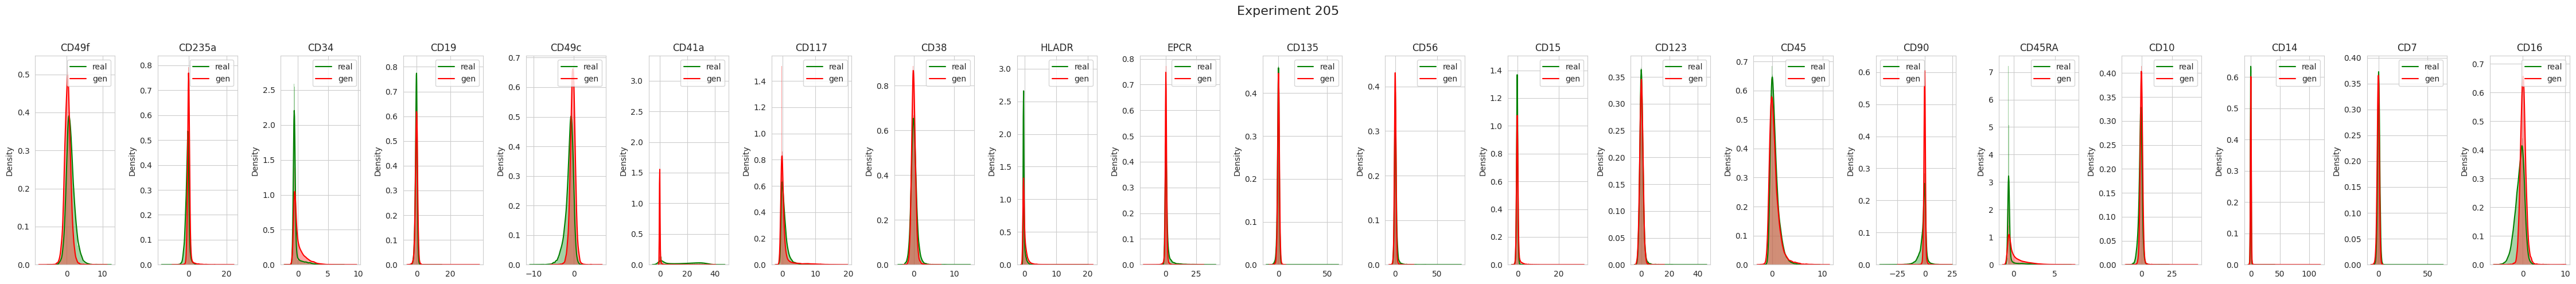

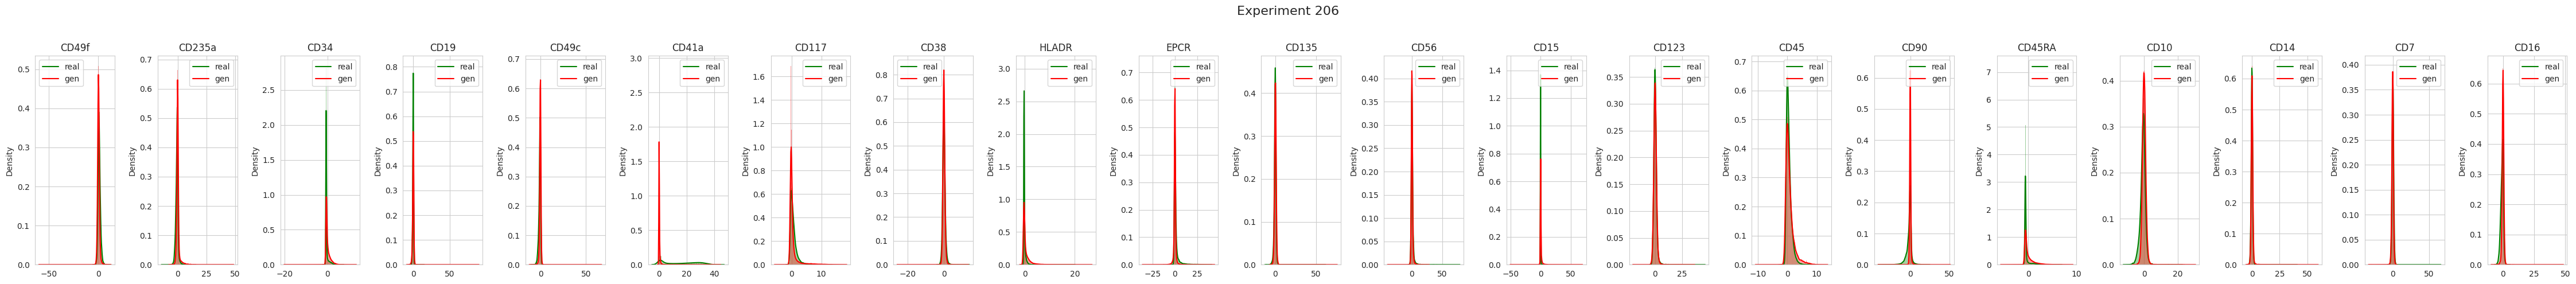

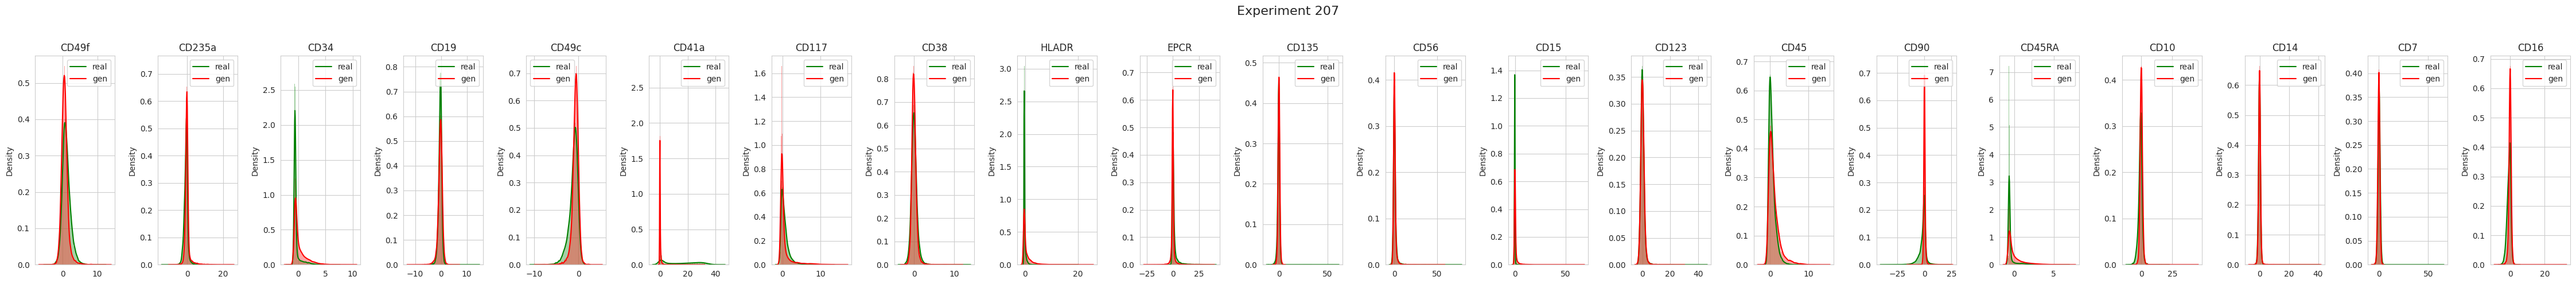

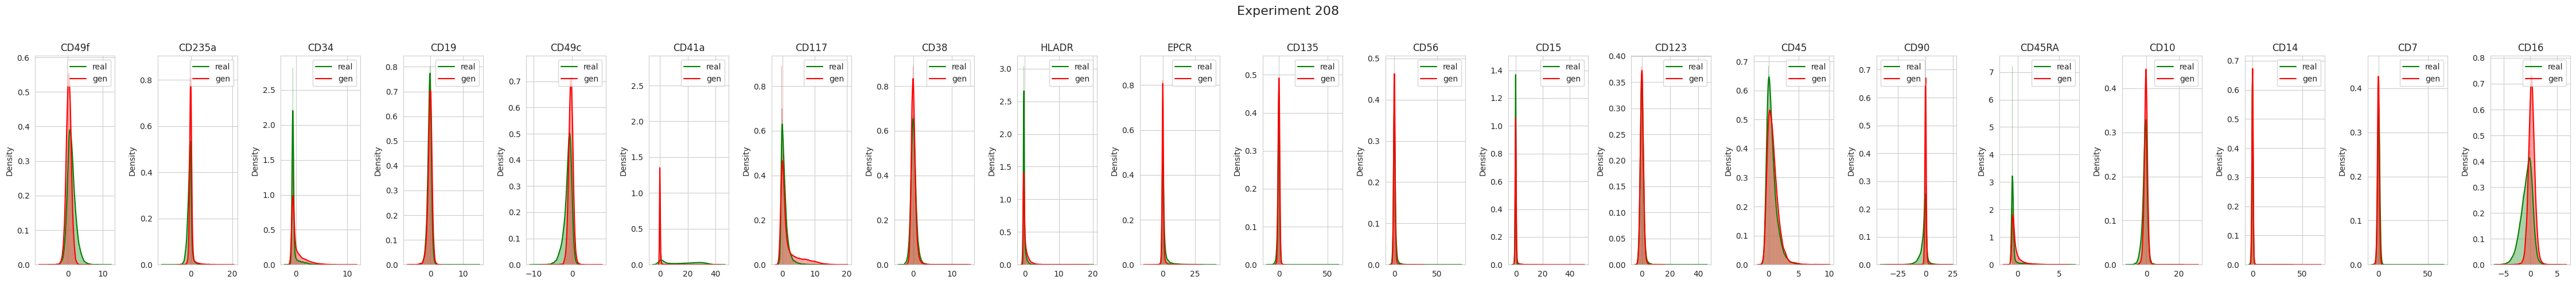

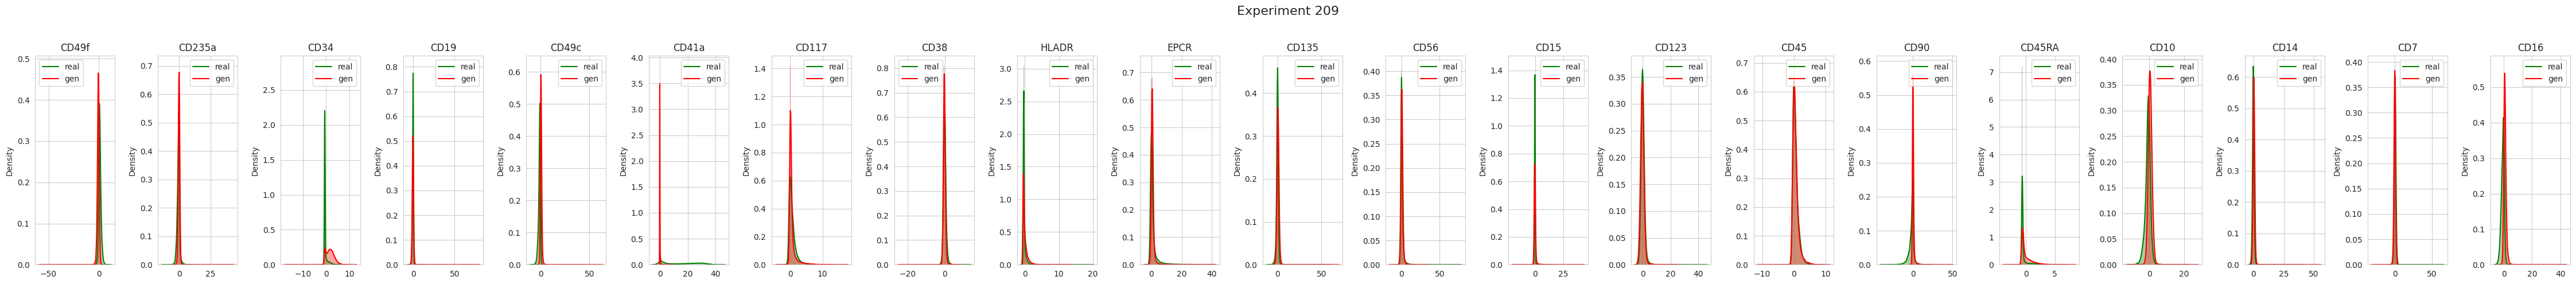

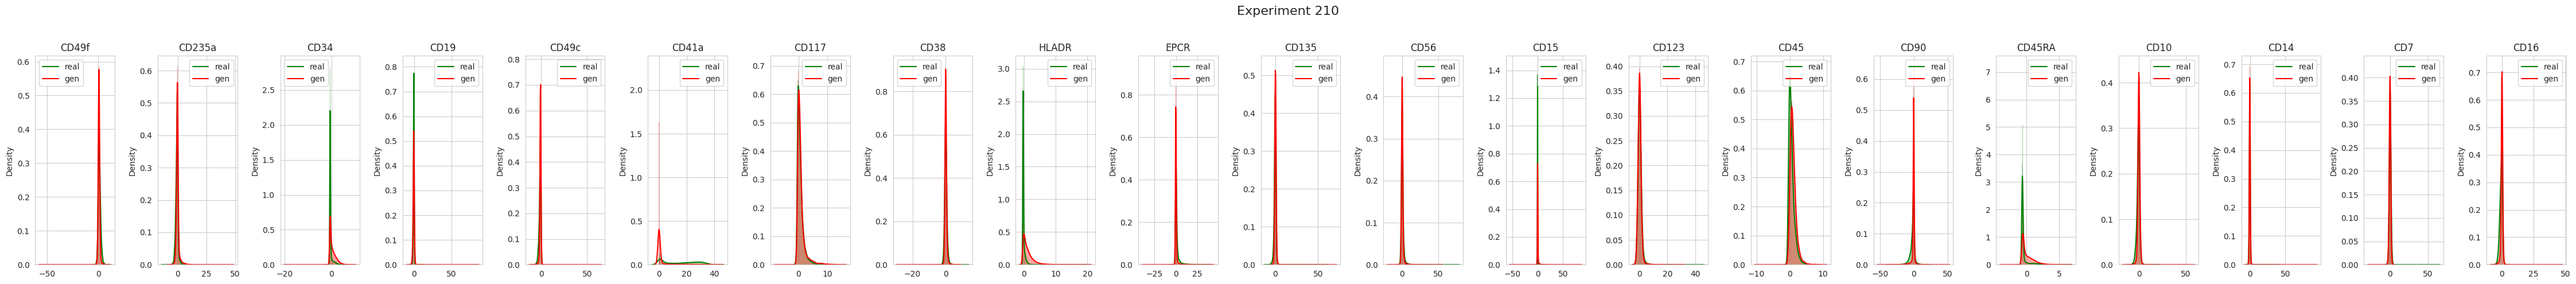

In [ ]:
from plot_utils import plot_marginals
adata_ref = cfm.train_data.adata
for gen_idx, gen_exp_number in enumerate(exp_numbers):
    # retrieve simulations for current experiment
    X_channel_gen = sim_data["X_channel"][:, gen_idx, :]
    X_scatter_gen = sim_data["X_scatter"][:, gen_idx, :]
    ct_probs_gen = sim_data["ct_probs"][:, gen_idx, :]

    # retrieve real data for current experiment
    adata_exp = adata_real[adata_real.obs["experiment_number"] == exp_number]
    X_channel_real = adata_exp.obsm["X_channel_standardized"]
    X_scatter_real = adata_exp.obsm["X_scatter_standardized"]

    plot_marginals(X_channel_real, X_gen=X_channel_gen, col_names=adata_real.var_names, title=f"Experiment {gen_exp_number}")
    # break

